In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('housing.csv',usecols = ['GarageQual','FireplaceQu','SalePrice'])

In [3]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [4]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

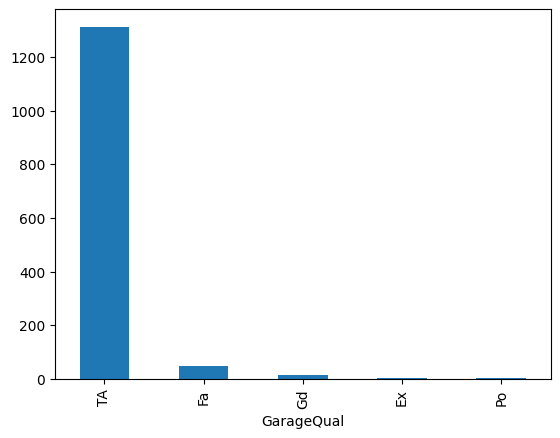

In [5]:
df['GarageQual'].value_counts().plot(kind = 'bar')

Text(0.5, 1.0, 'GarageQual vs SalePrice')

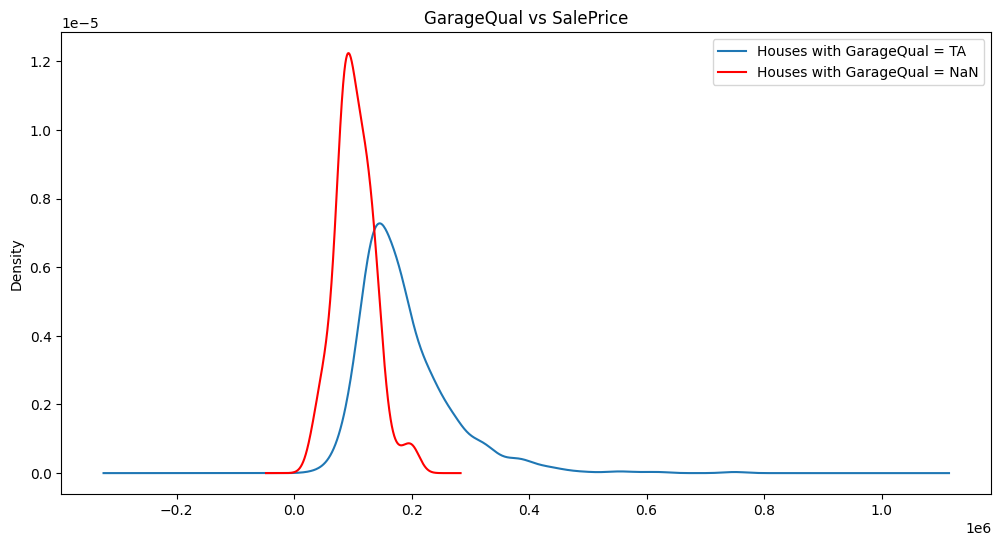

In [8]:
fig =plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind = 'kde',ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind = 'kde',ax=ax,color = 'red')

lines , labels = ax.get_legend_handles_labels()
labels = ['Houses with GarageQual = TA','Houses with GarageQual = NaN']
ax.legend(lines,labels,loc = 'best')
plt.title('GarageQual vs SalePrice')


In [9]:
temp =df[df['GarageQual'] == 'TA']['SalePrice']

In [10]:
df['GarageQual'].fillna('TA',inplace = True)

<Axes: xlabel='GarageQual'>

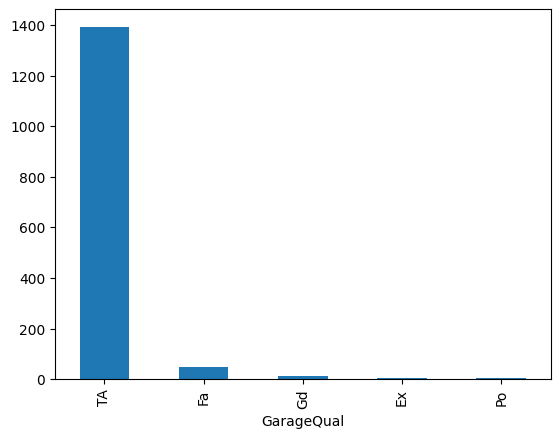

In [12]:
df['GarageQual'].value_counts().plot(kind = 'bar')

Text(0.5, 1.0, 'GarageQual')

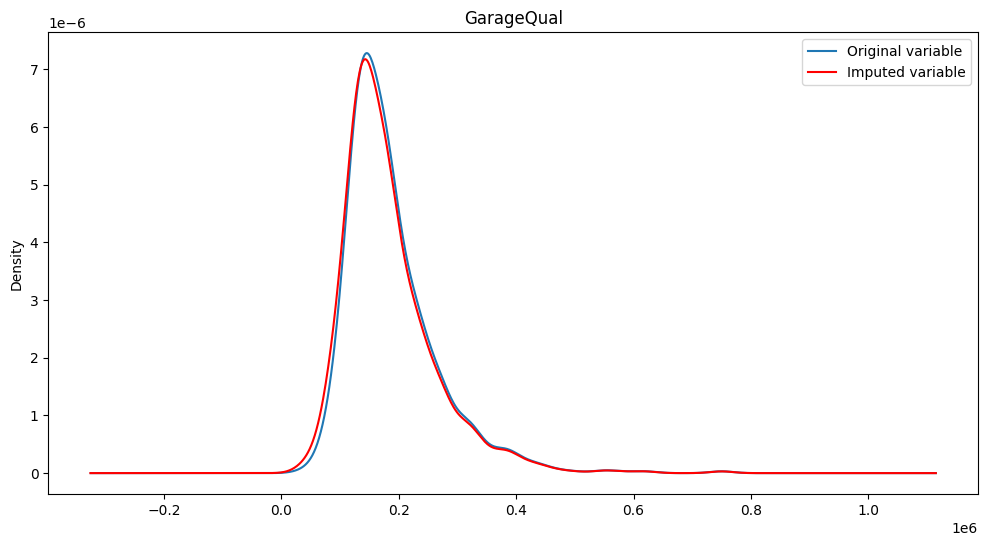

In [14]:
fig = plt.figure(figsize= (12,6))
ax = fig.add_subplot(111)

temp.plot(kind = 'kde' , ax =ax)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind = 'kde',ax=ax,color='red')

lines,labels = ax.get_legend_handles_labels()
labels = ['Original variable' , 'Imputed variable']
ax.legend(lines,labels,loc = 'best')

plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

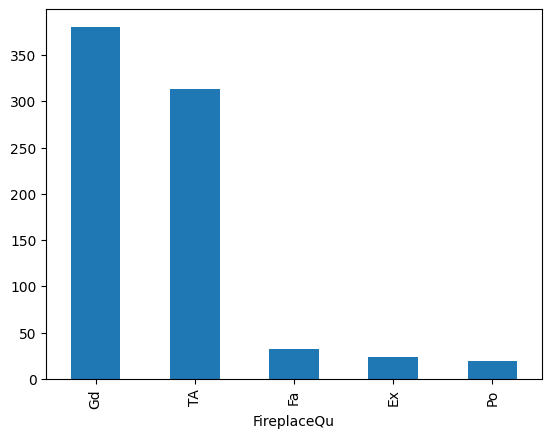

In [15]:
df['FireplaceQu'].value_counts().plot(kind = 'bar')

In [16]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

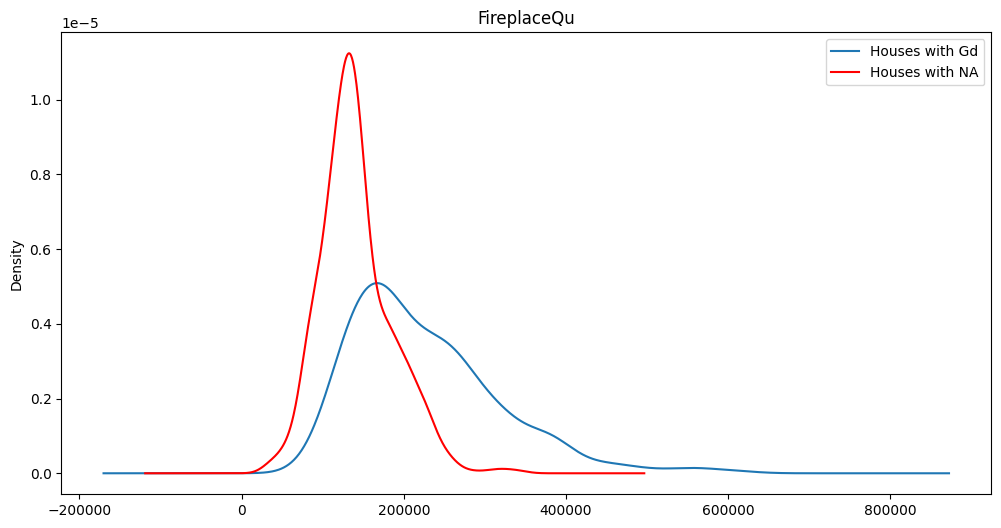

In [18]:
fig= plt.figure(figsize = (12,6))
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind = 'kde',ax = ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind = 'kde' ,ax=ax ,color = 'red')

lines,labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd','Houses with NA']
ax.legend(lines,labels , loc = 'best')

plt.title('FireplaceQu')

<Axes: xlabel='FireplaceQu'>

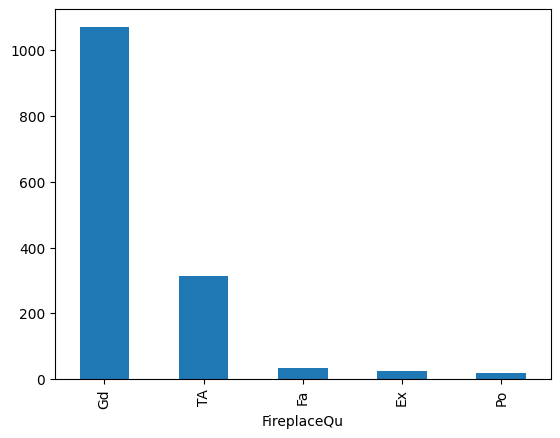

In [20]:
temp  = df[df['FireplaceQu'] == 'Gd']['SalePrice']

df['FireplaceQu'].fillna('Gd',inplace = True)

df['FireplaceQu'].value_counts().plot(kind = 'bar')

Text(0.5, 1.0, 'FireplaceQu')

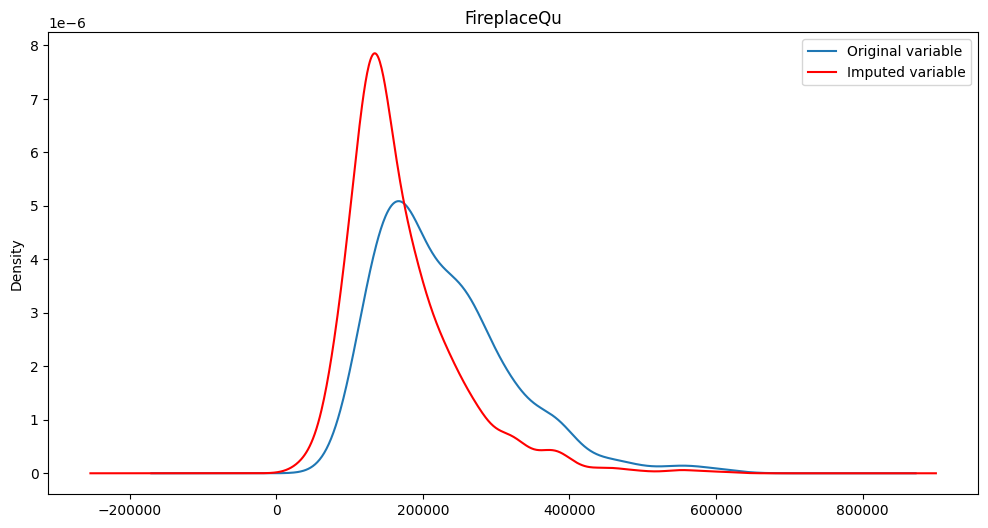

In [25]:
fig = plt.figure(figsize = (12,6))
ax = fig.add_subplot(111)

temp.plot(kind = 'kde',ax=ax)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind ='kde',ax=ax,color= 'red')

lines,labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines,labels,loc= 'best')

plt.title('FireplaceQu')

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test , y_train,y_test  = train_test_split(df.drop('SalePrice',axis = 1),df['SalePrice'],test_size = 0.2)

In [27]:
from sklearn.impute import SimpleImputer

In [30]:
imputer = SimpleImputer(strategy = 'most_frequent')


In [31]:

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [32]:

imputer.statistics_

array(['Gd', 'TA'], dtype=object)